In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset

In [ ]:
df = pd.read_csv('flights.csv') 

df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [82]:

df.tail()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
271883,135941,1339,Campo Grande (MS),Florianopolis (SC),firstClass,1446.34,1.49,573.81,CloudFy,07/12/2020
271884,135942,1339,Florianopolis (SC),Natal (RN),economic,726.95,1.84,709.37,CloudFy,07/16/2020
271885,135942,1339,Natal (RN),Florianopolis (SC),economic,873.07,1.84,709.37,CloudFy,07/20/2020
271886,135943,1339,Florianopolis (SC),Rio de Janeiro (RJ),economic,313.62,1.21,466.30,CloudFy,07/23/2020
271887,135943,1339,Rio de Janeiro (RJ),Florianopolis (SC),economic,533.69,1.21,466.30,CloudFy,07/26/2020


### Understand the dataset

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  str    
 3   to          271888 non-null  str    
 4   flightType  271888 non-null  str    
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  str    
 9   date        271888 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 35.0 MB


In [84]:
print("Duplicate values in the dataset: ")
print(df.duplicated().sum())
print("--------------------------")
print("Missing values in the dataset: ")
print(df.isnull().sum())

Duplicate values in the dataset: 
0
--------------------------
Missing values in the dataset: 
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64


In [85]:
df.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


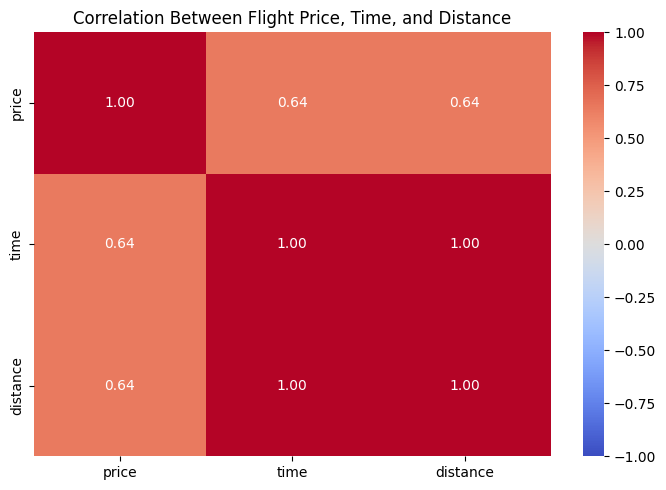

In [ ]:
# Correlation heatmap for meaningful numeric flight measures

numeric_features = ['price', 'time', 'distance']
correlation = df[numeric_features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Between Flight Price, Time, and Distance')
plt.tight_layout()
plt.show()

In [87]:
df["price"].head()

0    1434.38
1    1292.29
2    1487.52
3    1127.36
4    1684.05
Name: price, dtype: float64

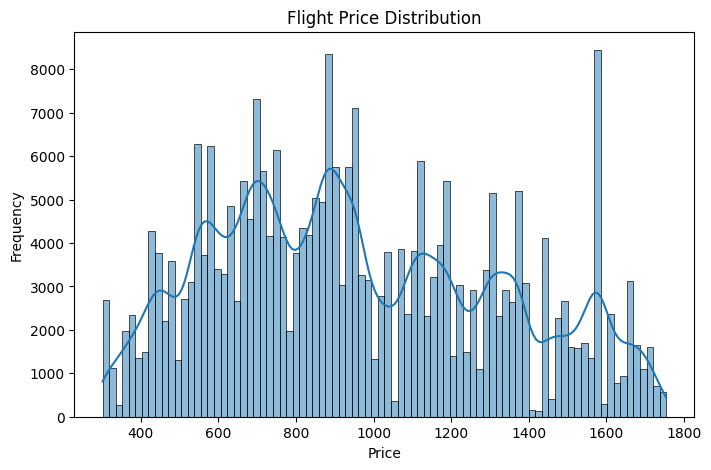

In [120]:
# Check the price distribution:

plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [89]:
print(df.dtypes)

travelCode      int64
userCode        int64
from              str
to                str
flightType        str
price         float64
time          float64
distance      float64
agency            str
date              str
dtype: object


### convert date into column 

In [90]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day

In [91]:
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,year,month,day
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,2019,10,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,2019,10,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10


### Fature selection and remove the prameters which is not usefull

In [92]:
df.drop("date", axis=1, inplace=True)

df.drop(["travelCode", "userCode"], axis=1, inplace=True)

In [93]:
df.head()

,from,to,flightType,price,time,distance,agency,year,month,day
0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019,9,26
1,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019,9,30
2,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019,10,3
3,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019,10,4
4,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019,10,10


### Convert categorical variables into numbers

In [94]:
from sklearn.preprocessing import LabelEncoder

le_from = LabelEncoder()
le_to = LabelEncoder()
le_flightType = LabelEncoder()
le_agency = LabelEncoder()

df["from"] = le_from.fit_transform(df["from"])

df["to"] = le_to.fit_transform(df["to"])

df["flightType"] = le_flightType.fit_transform(df["flightType"])

df["agency"] = le_agency.fit_transform(df["agency"])

In [95]:
df.head()

,from,to,flightType,price,time,distance,agency,year,month,day
0,5,3,1,1434.38,1.76,676.53,1,2019,9,26
1,3,5,1,1292.29,1.76,676.53,1,2019,9,30
2,1,3,1,1487.52,1.66,637.56,0,2019,10,3
3,3,1,1,1127.36,1.66,637.56,0,2019,10,4
4,0,7,1,1684.05,2.16,830.86,0,2019,10,10


### Check Correlation amoung the parameters

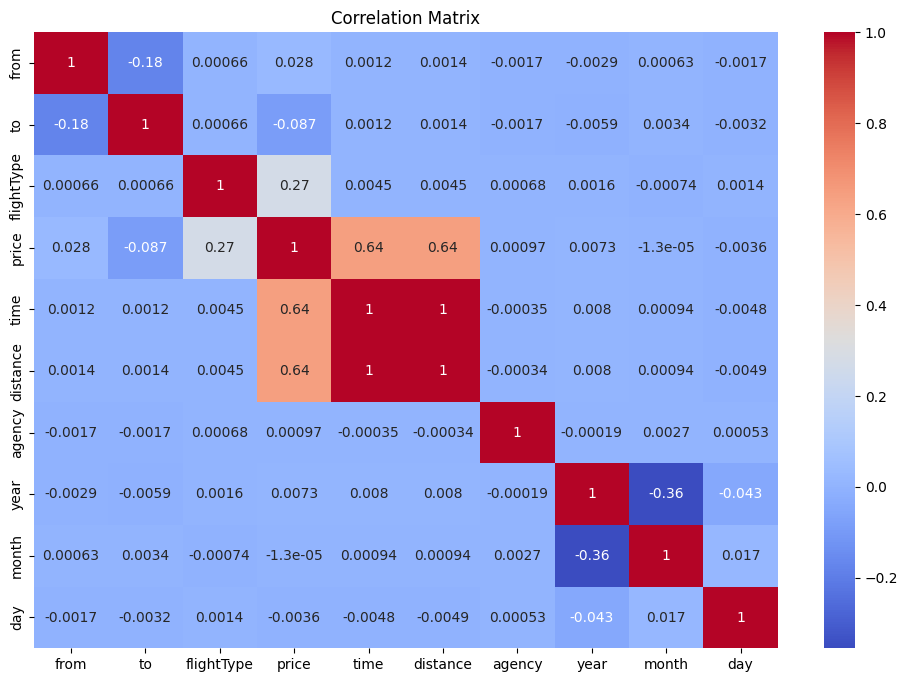

In [96]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [97]:
print(df.corr()["price"].sort_values(ascending=False))

price         1.000000
distance      0.641915
time          0.641800
flightType    0.272147
from          0.028157
year          0.007291
agency        0.000974
month        -0.000013
day          -0.003572
to           -0.087037
Name: price, dtype: float64


### Separate features and target

In [98]:
X = df.drop("price", axis=1)
y = df["price"]

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

### Split the dataset into
 70% - Training
 30% - Testing

In [100]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.30,random_state=42)

### Standard Scaling the train and test dataset for linear regression model

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [102]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression 

In [103]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression MAE:", linear_mae)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

print("Linear Regression RMSE:", linear_rmse)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression R2:", linear_r2)

Linear Regression MAE: 215.2238478542555
Linear Regression RMSE: 258.51176221746306
Linear Regression R2: 0.4917131504842348


### Decision tree

In [104]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [105]:
tree_mae = mean_absolute_error(y_test, tree_pred)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2:", tree_r2)

Decision Tree MAE: 0.08687324531260313
Decision Tree RMSE: 2.6433277356886844
Decision Tree R2: 0.9999468564841155


### Random Forest

In [106]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [107]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 0.08453859894568079
Random Forest RMSE: 0.83450246905052
Random Forest R2: 0.9999947033227615


### Comparing the Models 

In [108]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,215.223848,258.511762,0.491713
1,Decision Tree,0.086873,2.643328,0.999947
2,Random Forest,0.084539,0.834502,0.999995


### Check important parameters which are responsible for predict the flight price

In [109]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,flightType,0.373430
3,time,0.239760
4,distance,0.217451
1,to,0.106173
0,from,0.057788
5,agency,0.005370
8,day,0.000013
7,month,0.000009
6,year,0.000005


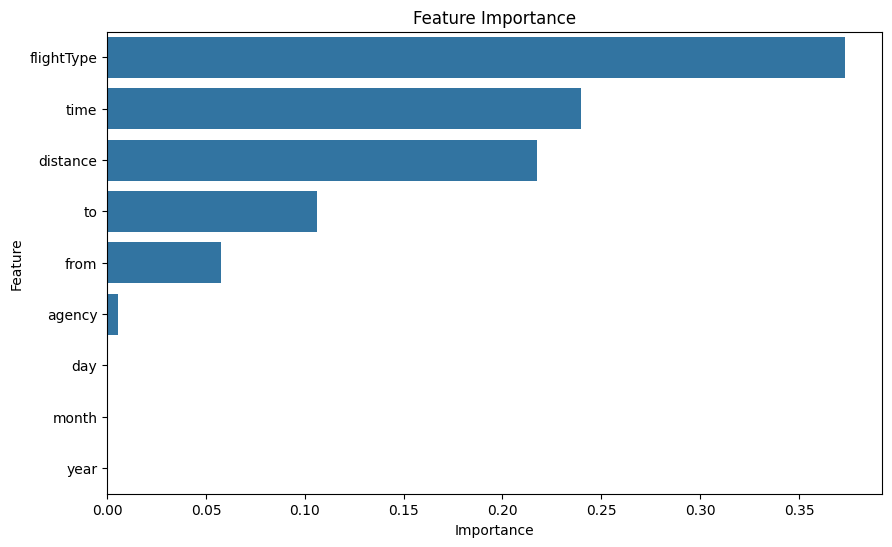

In [121]:
# Check the feature importance: By ploting the graph 

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

### Actual vs Predicted Price

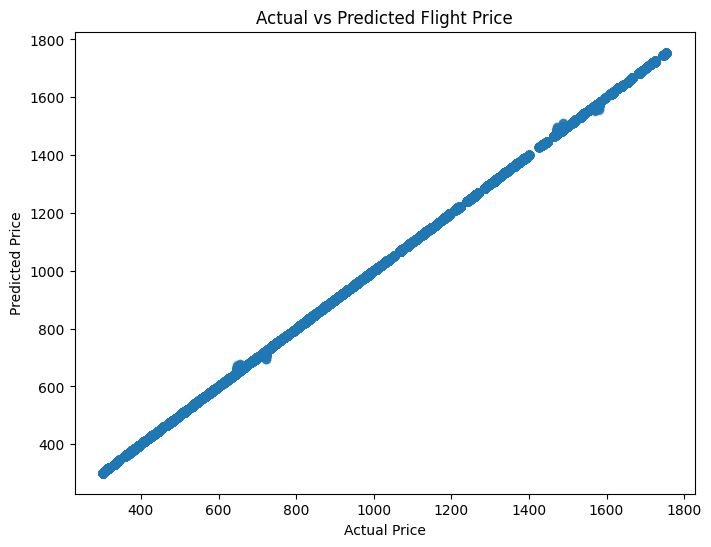

In [111]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Flight Price")

plt.show()

### Check actual and predicted prices

In [112]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_pred
})

comparison.head(20)


,Actual Price,Predicted Price
0,481.42,481.4200
1,1124.11,1124.1100
2,1174.97,1174.9700
3,898.67,898.6700
4,959.91,959.9100
5,1367.60,1367.6000
6,762.89,762.8900
7,1569.65,1569.7715
8,835.21,835.2100
9,674.52,674.5200


### Predict the price of a new flight

In [113]:
new_flight = pd.DataFrame({
    "from": [0],
    "to": [2],
    "flightType": [1],
    "time": [150],
    "distance": [1000],
    "agency": [0],
    "year": [2023],
    "month": [5],
    "day": [15],
    
})

predicted_price = rf_model.predict(new_flight)

print("Predicted Flight Price:", predicted_price[0])

Predicted Flight Price: 1663.173999999996


### Save the trained model

In [119]:
import joblib

joblib.dump(rf_model, "flight_price_model.joblib")

joblib.dump(le_from, "from_encoder.joblib")

joblib.dump(le_to, "to_encoder.joblib")

joblib.dump(le_flightType, "flightType_encoder.joblib")

joblib.dump(le_agency, "agency_encoder.joblib")

['agency_encoder.joblib']